# Pipeline Tag Prediction
## Baseline - TF-IDF & Logistic Regression

**DATASCI 266: Natural Language Processing with Deep Learning**

UC Berkeley, School of Information

---

This notebook implements the baseline model using TF-IDF and Logistic Regression. It runs in this order:

1. Load cleaned dataset
2. Train/test/validation split
3. Format model card text
5. Setup TF-IDF and encode labels
6. Logistic regression model
7. Predictions and metric analysis
8. Export dataframes for improvement models

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings, re, ast
from datasets import load_dataset, DatasetDict

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# Plot defaults
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (12, 5)})

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load Cleaned Dataset

Importing the cleaned dataset from `model_cards_cleaned.parquet`. See data cleaning file for specifics.

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd, json

DRIVE_DIR = '/content/drive/MyDrive/266-pipeline-tag-prediction'
df = pd.read_parquet(f'{DRIVE_DIR}/model_cards_cleaned.parquet')
metadata = json.load(open(f'{DRIVE_DIR}/metadata.json'))
label2id, id2label = metadata['label2id'], metadata['id2label']

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Preview dataset for current columns and data formats
df.head()

,modelId,pipeline_tag,label,text,char_len,word_count
0,00000tt/OmniDream-LoRas,text-to-image,7,# OmniDream FinalDream LoRas\n\n<Gallery />\n\...,305,40
1,00001a/gemma-4-26B-A4B-it-uncensored-heretic-a...,image-text-to-text,2,# 🦆 zecanard/gemma-4-26B-A4B-it-uncensored-her...,1343,139
2,001szp/Qwen3.5-27B-Claude-4.6-Opus-Reasoning-D...,image-text-to-text,2,# 🌟 Qwen3.5-27B-Claude-4.6-Opus-Reasoning-Dist...,7758,919
3,0057Kanyakorn/distilbert-base-uncased-finetune...,text-classification,5,<!-- This model card has been generated automa...,1425,187
4,006aman/IKS-Mistral-7B,text-generation,6,# Uploaded finetuned model\n\n- **Developed b...,442,33


In [4]:
df.count()

,0
modelId,141036
pipeline_tag,141036
label,141036
text,141036
char_len,141036
word_count,141036


In [5]:
df.value_counts("pipeline_tag")

,count
pipeline_tag,
text-generation,67841
text-to-image,21831
image-text-to-text,12309
text-classification,10218
translation,8589
automatic-speech-recognition,5829
token-classification,4033
sentence-similarity,3726
robotics,3355


## 2. Split Data

Split the data into train, validation, and test dataframes using an 80/20/20 split.

In [6]:
# train/test split
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)

In [7]:
# val split
test_df, val_df = train_test_split(temp_df, test_size=0.5, random_state=42)

In [8]:
# Verify shapes for each df
print("Shape of train:", train_df.shape)
print("Shape of validation:", val_df.shape)
print("Shape of test:", test_df.shape)

Shape of train: (112828, 6)
Shape of validation: (14104, 6)
Shape of test: (14104, 6)


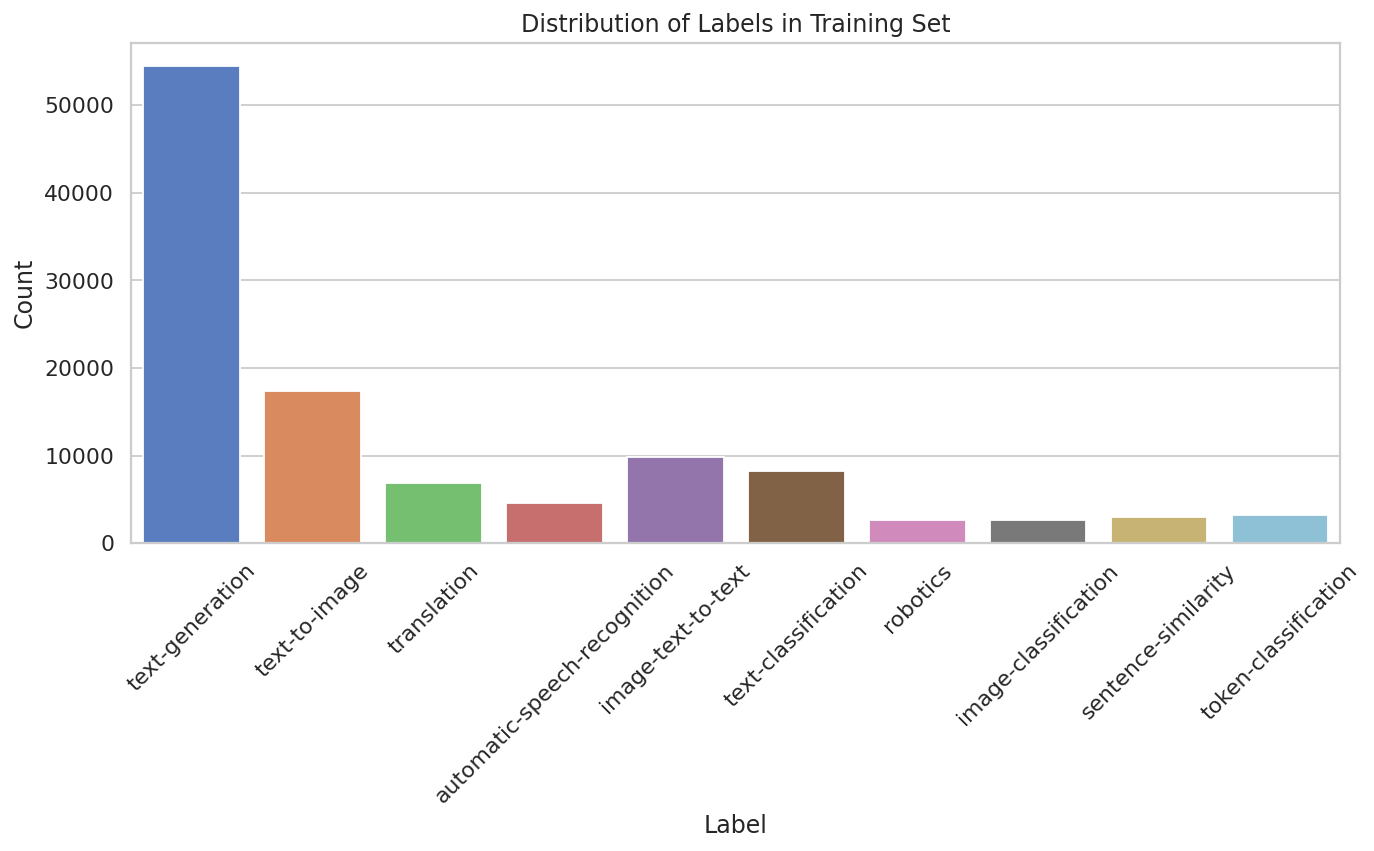

,count
pipeline_tag,
text-generation,54420
text-to-image,17415
image-text-to-text,9810
text-classification,8191
translation,6842
automatic-speech-recognition,4613
token-classification,3247
sentence-similarity,3001
robotics,2667


In [9]:
# Preview label distribution in the training dataset
sns.countplot(x='pipeline_tag', data=train_df, hue='pipeline_tag')
plt.title("Distribution of Labels in Training Set")
plt.xlabel("Label")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

train_df["pipeline_tag"].value_counts()

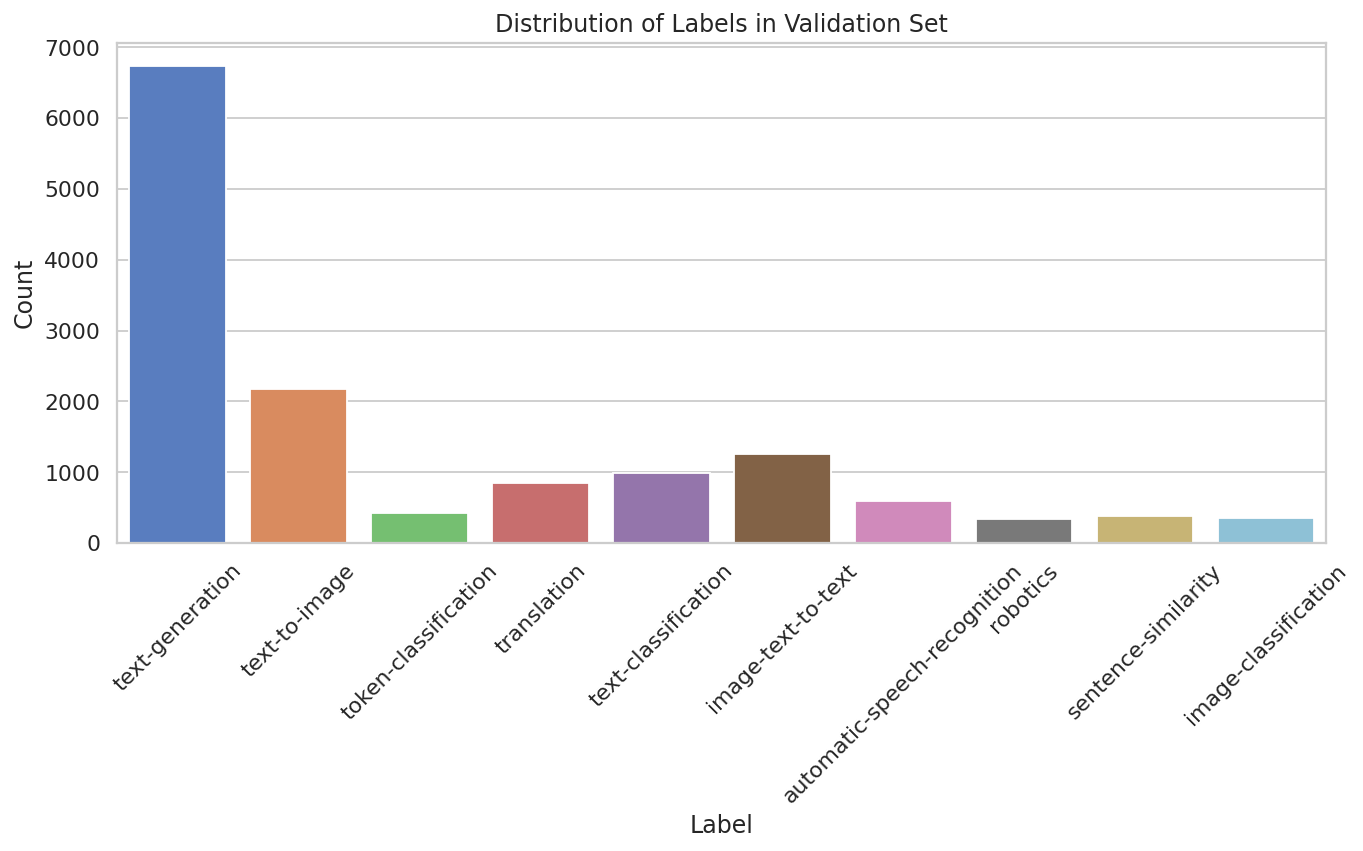

,count
pipeline_tag,
text-generation,6732
text-to-image,2177
image-text-to-text,1259
text-classification,994
translation,844
automatic-speech-recognition,599
token-classification,424
sentence-similarity,382
image-classification,352


In [10]:
# Preview label distribution in the validation dataset
sns.countplot(x='pipeline_tag', data=val_df, hue='pipeline_tag')
plt.title("Distribution of Labels in Validation Set")
plt.xlabel("Label")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

val_df["pipeline_tag"].value_counts()

## 3. Format Inputs

Clean the model card text by changing all letters to lowercase, removing punctuation, removing numbers, and collapsing whitespace, prior to fitting the data.

In [11]:
# Define cleaning function
def clean_text(text: str) -> str:
    """Lowercase, remove punctuation/numbers, collapse whitespace."""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
# Apply clean_text to train set
train_df['text_clean']  = train_df['text'].apply(clean_text)
# Apply clean_text to test set
test_df['text_clean']  = test_df['text'].apply(clean_text)
# Apply clean_text to validation set
val_df['text_clean']  = val_df['text'].apply(clean_text)

Print a cleaned example:

In [12]:
# raw unformatted:
print(f'\ntrain: raw answer  : "{train_df["text"].iloc[0]}"')


train: raw answer  : "# Mellum2 Instruct — GGUF (BF16)

This repository contains a **GGUF BF16** quantization of
[`JetBrains/Mellum2-12B-A2.5B-Instruct`](https://huggingface.co/JetBrains/Mellum2-12B-A2.5B-Instruct), ready to run with
[`llama.cpp`](https://github.com/ggml-org/llama.cpp), Ollama, LM Studio, and
other GGUF-compatible runtimes.

**This quantization (BF16):** 16-bit, **no quantization**. The reference these quants are measured against; largest file.

| File | Size |
|---|---|
| `Mellum2-12B-A2.5B-Instruct-BF16.gguf` | 24.3 GB |

Mellum 2 Instruct is a Mixture-of-Experts assistant model (64 experts, 8
activated per token, 131,072-token context) that answers directly, without an
externalized chain of thought. For the full model description, evaluation
results, and architecture details, see the original model card:
**[JetBrains/Mellum2-12B-A2.5B-Instruct](https://huggingface.co/JetBrains/Mellum2-12B-A2.5B-Instruct)**.

## Available quantizations

| Quantization | Description 

In [13]:
# cleaned
print(f'train: clean answer : "{train_df["text_clean"].iloc[0]}"')

train: clean answer : "mellum instruct gguf bf this repository contains a gguf bf quantization of jetbrains mellum b a b instruct https huggingface co jetbrains mellum b a b instruct ready to run with llama cpp https github com ggml org llama cpp ollama lm studio and other gguf compatible runtimes this quantization bf bit no quantization the reference these quants are measured against largest file file size mellum b a b instruct bf gguf gb mellum instruct is a mixture of experts assistant model experts activated per token token context that answers directly without an externalized chain of thought for the full model description evaluation results and architecture details see the original model card jetbrains mellum b a b instruct https huggingface co jetbrains mellum b a b instruct available quantizations quantization description size kld vs bf top token match bf this repo bit no quantization reference gb q https huggingface co jetbrains mellum b a b instruct gguf q bit effectively los

## 4. TF-IDF & Encoding

Setup the TF-IDF vectorizer. Set the max_features to 20,000 as a starting point. Encode the `pipeline_tag` labels. Fit data with training and validation sets. Do not fit using test data.

In [14]:
# Set TF-IDF
# using default norm, l2 for cosine similarity
tf_idf_vec = TfidfVectorizer(max_features=20000, # top 20k features
                             ngram_range=(1,2), # allows bigrams and unigrams
                             sublinear_tf=True, # allow sublinear scaling to reduce skewing to most frequent words (applies a log to term frequency)
                             min_df=5, # dropping any words that show up <5 times
                             )

In [15]:
label_encoder = LabelEncoder()

# Fit w/ training and val
X_train = tf_idf_vec.fit_transform(train_df["text_clean"])
X_val = tf_idf_vec.transform(val_df["text_clean"])

# Fit w/ test
X_test = tf_idf_vec.transform(test_df["text_clean"])

# Encode text labels to int categories
Y_train = label_encoder.fit_transform(train_df["pipeline_tag"])
Y_val = label_encoder.transform(val_df["pipeline_tag"])
Y_test = label_encoder.transform(test_df["pipeline_tag"])

# Print shapes for review
print("Shape of formatted X_train:", X_train.shape)
print("Shape of formatted X_val:", X_val.shape)
print("Shape of formatted X_test:", X_test.shape)
print("Shape of formatted Y_train:", Y_train.shape)
print("Shape of formatted Y_val:", Y_val.shape)
print("Shape of formatted Y_test:", Y_test.shape)

Shape of formatted X_train: (112828, 20000)
Shape of formatted X_val: (14104, 20000)
Shape of formatted X_test: (14104, 20000)
Shape of formatted Y_train: (112828,)
Shape of formatted Y_val: (14104,)
Shape of formatted Y_test: (14104,)


## 5. Logistic Regression Baseline

In [16]:
# Baseline w/ Logistic Regression
lr_model = LogisticRegression(max_iter=1000,
                              class_weight="balanced",
                              random_state=42,
                              n_jobs=-1
                              )

lr_model.fit(X_train, Y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1,
                   random_state=42)

## 6. Predictions and Metrics

Use the logistic regression model to generate predictions for the validation and finally the test datasets. Generate accuracy and macro-F1 scores to evaluate the model on each dataset.

In [17]:
# Save predictions
val_predictions = lr_model.predict(X_val)
test_predictions = lr_model.predict(X_test)

In [18]:
# Print relevant metrics
print("Validation Accuracy:", accuracy_score(Y_val, val_predictions))
print("Validation Macro-F1:", f1_score(Y_val, val_predictions, average="macro"))

print("Test Accuracy:", accuracy_score(Y_test, test_predictions))
print("Test Macro-F1:", f1_score(Y_test, test_predictions, average="macro"))

Validation Accuracy: 0.9468235961429382
Validation Macro-F1: 0.9500192145851521
Test Accuracy: 0.9447674418604651
Test Macro-F1: 0.9472047717696157


In [19]:
# Print classification report to analyze metrics per `pipeline_tag` label
print(classification_report(Y_test, test_predictions, target_names=label_encoder.classes_))

                              precision    recall  f1-score   support

automatic-speech-recognition       0.98      0.98      0.98       617
        image-classification       0.95      0.97      0.96       331
          image-text-to-text       0.74      0.91      0.82      1240
                    robotics       0.94      0.99      0.96       347
         sentence-similarity       0.98      0.98      0.98       343
         text-classification       0.90      0.95      0.92      1033
             text-generation       0.97      0.92      0.95      6689
               text-to-image       0.99      0.99      0.99      2239
        token-classification       0.93      0.94      0.94       362
                 translation       0.97      0.96      0.97       903

                    accuracy                           0.94     14104
                   macro avg       0.94      0.96      0.95     14104
                weighted avg       0.95      0.94      0.95     14104



## 7. Export data

Export the train, test, and validation dataframes to use the exact same data split for the improvement models: RoBERTa and ModernBERT. This ensures consistency in our metric and model evaluations.

In [20]:
# Set new google drive directory path
DRIVE_DIR_2 = '/content/drive/MyDrive/266-pipeline-tag-prediction'
# Save each dataframe to a parquet
train_df.to_parquet(f'{DRIVE_DIR}/train_df.parquet', index=False)
val_df.to_parquet(f'{DRIVE_DIR}/val_df.parquet', index=False)
test_df.to_parquet(f'{DRIVE_DIR}/test_df.parquet', index=False)

To load these dataframes into a new notebook for the improvement model, use this code block:

```python
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd, json

DRIVE_DIR_2 = '/content/drive/MyDrive/266-pipeline-tag-prediction'

train_df = pd.read_parquet(f'{DRIVE_DIR_2}/train_df.parquet')
val_df = pd.read_parquet(f'{DRIVE_DIR_2}/val_df.parquet')
test_df = pd.read_parquet(f'{DRIVE_DIR_2}/test_df.parquet')

metadata = json.load(open(f'{DRIVE_DIR_2}/metadata.json'))
label2id, id2label = metadata['label2id'], metadata['id2label']
```

## 00. random working space

misc data checks - `delete later`

In [21]:
max_length = train_df["text"].str.len().max()
max_length

99615

In [22]:
avg_len = train_df["text"].str.len().mean()
avg_len

np.float64(4376.627060658701)

In [23]:
train_df["text"].str.len().describe()

,text
count,112828.000000
mean,4376.627061
std,7910.142902
min,100.000000
25%,1075.000000
50%,2041.000000
75%,4517.250000
max,99615.000000
